# Barry Plant External Validation

This notebook evaluates the previously trained rental-price model on the 2026 Barry Plant validation dataset.

The Barry Plant data are used only for external validation and are not used for model fitting, feature selection or hyperparameter tuning.

Because the training data are from Domain in 2025 and the validation data are from Barry Plant in 2026, this evaluation reflects both temporal and platform differences.

## 1. Load validation data and trained model

In [1]:
from pathlib import Path
import hashlib
import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
TRAINING_PATH = PROJECT_ROOT / "data/curated/master_modelling_table.parquet"
VALIDATION_PATH = PROJECT_ROOT / "data/curated/plant_validation_features.parquet"
MODEL_PATH = PROJECT_ROOT / "models/rental_best_model.joblib"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

numeric_features = [
    "bedrooms", "bathrooms", "carspaces", "route_km_to_cbd",
    "est_route_km_to_nearest_station", "straight_km_to_nearest_school",
    "straight_km_to_nearest_park", "straight_km_to_nearest_mall",
    "n_stations_within_1km", "n_schools_within_1km", "n_parks_within_500m",
    "income_median", "population_growth_5y", "population_density_2026",
]
categorical_features = ["primary_type", "suburb"]
features = numeric_features + categorical_features
best_params = dict(learning_rate=0.2, max_depth=4, min_samples_leaf=3, n_estimators=500)

### Restore the selected model

No fitted pipeline was exported by `04_rental_price_model.ipynb`. On the first run, reconstruct it using the same Domain filters, splits, preprocessing and selected parameters, then save it. Subsequent runs load the artifact. Reconstruction can vary with the training file or scikit-learn version; provenance is stored in the artifact. Barry Plant data never enter fitting.

In [2]:
# Reconstruct only if the trained artifact has not yet been saved.
# These are the selected parameters from 04, not a new tuning run.
if not MODEL_PATH.exists():
    domain = pd.read_parquet(TRAINING_PATH)
    if "is_modelling_ready" in domain.columns:
        domain = domain[domain["is_modelling_ready"]].copy()
    domain = domain[domain["weekly_rent"].notna() & domain["weekly_rent"].gt(0)].copy()
    assert set(features).issubset(domain.columns), "Training features are missing"
    X_domain = domain[features].copy()
    y_domain_log = np.log1p(domain["weekly_rent"])

    # Reproduce both random splits AND concatenation order from 04.
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_domain, y_domain_log, test_size=0.20, random_state=RANDOM_STATE,
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE,
    )
    preprocessor = ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ], remainder="drop")
    reconstructed_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(**best_params, random_state=RANDOM_STATE)), # pyright: ignore[reportArgumentType]
    ])
    reconstructed_pipe.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    artifact = {
        "pipeline": reconstructed_pipe, # pyright: ignore[reportUndefinedVariable]
        "features": features,
        "best_params": best_params,
        "target_transform": "log1p",
        "sklearn_version": sklearn.__version__,
        "training_source": "data/curated/master_modelling_table.parquet",
        "training_sha256": hashlib.sha256(TRAINING_PATH.read_bytes()).hexdigest(),
        "fit_rows": len(X_train) + len(X_val),
        "held_out_rows": len(X_test),
        "random_state": RANDOM_STATE,
    }
    joblib.dump(artifact, MODEL_PATH)
    print("Reconstructed and saved using Domain data only.")
else:
    print("Saved model found; no fitting required.")


Saved model found; no fitting required.


### Load the pipeline and align external inputs

Keep the fitted imputers, scaler and one-hot encoder. Do not fit preprocessing on the external data.

In [3]:
# Load the complete fitted preprocessor + model, not just the estimator.
model_artifact = joblib.load(MODEL_PATH)
assert model_artifact["features"] == features
assert model_artifact["best_params"] == best_params
assert model_artifact["target_transform"] == "log1p"
assert model_artifact["sklearn_version"] == sklearn.__version__, "Use the saved model's sklearn version"
final_pipe = model_artifact["pipeline"]
check_is_fitted(final_pipe.named_steps["model"])
assert list(final_pipe.feature_names_in_) == features

plant_validation = pd.read_parquet(VALIDATION_PATH)
missing_columns = set(features + ["weekly_rent", "listing_id"]) - set(plant_validation.columns)
assert not missing_columns, f"Missing validation columns: {missing_columns}"
assert plant_validation["listing_id"].is_unique
assert plant_validation["weekly_rent"].notna().all()
assert plant_validation["weekly_rent"].gt(0).all()
X_external = plant_validation[features].copy()
y_external = plant_validation["weekly_rent"].copy()
assert not np.isinf(X_external[numeric_features].to_numpy(dtype=float)).any()

print("Loaded:", type(final_pipe.named_steps["model"]).__name__)
print("Parameters:", model_artifact["best_params"])
print("Domain fit / held-out rows:", model_artifact["fit_rows"], "/", model_artifact["held_out_rows"])
print("External validation input:", X_external.shape)
print("Missing input values:", int(X_external.isna().sum().sum()))
print("Ready for prediction. Model output is log1p rent; convert with np.expm1.")


Loaded: GradientBoostingRegressor
Parameters: {'learning_rate': 0.2, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 500}
Domain fit / held-out rows: 9554 / 2389
External validation input: (719, 16)
Missing input values: 0
Ready for prediction. Model output is log1p rent; convert with np.expm1.


## 2. External validation performance

The fitted Gradient Boosting pipeline is applied directly to the Barry Plant data without refitting or recalibrating any preprocessing steps.

In [4]:
pred_log = final_pipe.predict(X_external)
y_pred = np.expm1(pred_log)

mae_external = mean_absolute_error(y_external, y_pred)
rmse_external = mean_squared_error(y_external, y_pred) ** 0.5
r2_external = r2_score(y_external, y_pred)

print("Barry Plant external validation")
print(f"N: {len(y_external)}")
print(f"MAE: ${mae_external:.2f} per week")
print(f"RMSE: ${rmse_external:.2f}")
print(f"R^2: {r2_external:.3f}")

Barry Plant external validation
N: 719
MAE: $62.61 per week
RMSE: $92.70
R^2: 0.728


## 3. Comparison with internal performance

Internal test performance provides a reference point for evaluating how well the model transfers to a different platform and a later time period.

In [5]:
# Internal metrics reproduced from 04_rental_price_model.ipynb
comparison = pd.DataFrame({
    "Evaluation": ["Domain random test", "Domain time test", "Barry Plant external validation"],
    "MAE": [74.82, 72.95, mae_external],
    "RMSE": [155.42, 129.02, rmse_external],
    "R2": [0.680, 0.686, r2_external]
})

comparison

,Evaluation,MAE,RMSE,R2
0,Domain random test,74.820000,155.420000,0.680000
1,Domain time test,72.950000,129.020000,0.686000
2,Barry Plant external validation,62.614341,92.697289,0.728141


## 4. Error diagnostics

In [6]:
validation_results = plant_validation[["listing_id", "weekly_rent", "suburb", "primary_type"]].copy()

validation_results["predicted_rent"] = y_pred
validation_results["error"] = (validation_results["predicted_rent"] - validation_results["weekly_rent"])
validation_results["absolute_error"] = (validation_results["error"].abs())

validation_results[["weekly_rent", "predicted_rent", "error", "absolute_error"]].describe()

,weekly_rent,predicted_rent,error,absolute_error
count,719.000000,719.000000,719.000000,719.000000
mean,608.052851,591.460804,-16.592047,62.614341
std,177.908868,148.175017,91.263769,68.401308
min,180.000000,203.130866,-874.269928,0.044424
25%,500.000000,500.912377,-56.543346,22.428877
50%,580.000000,570.605529,-10.416601,44.366526
75%,675.000000,654.961827,32.916292,82.263725
max,2200.000000,1611.695957,348.066131,874.269928


In [7]:
type_errors = (validation_results.groupby("primary_type")
                .agg(n=("listing_id", "size"),
                    actual_mean=("weekly_rent", "mean"),
                    predicted_mean=("predicted_rent", "mean"),
                    mae=("absolute_error", "mean"),
                    mean_error=("error", "mean"),
                ).sort_values("mae"))

type_errors

,n,actual_mean,predicted_mean,mae,mean_error
primary_type,,,,,
House,433,609.434180,595.519280,60.950464,-13.914900
Apartment,178,552.303371,534.776893,63.683703,-17.526478
Townhouse/Villa,108,694.398148,668.612804,67.522788,-25.785344


## 5. Visualisation

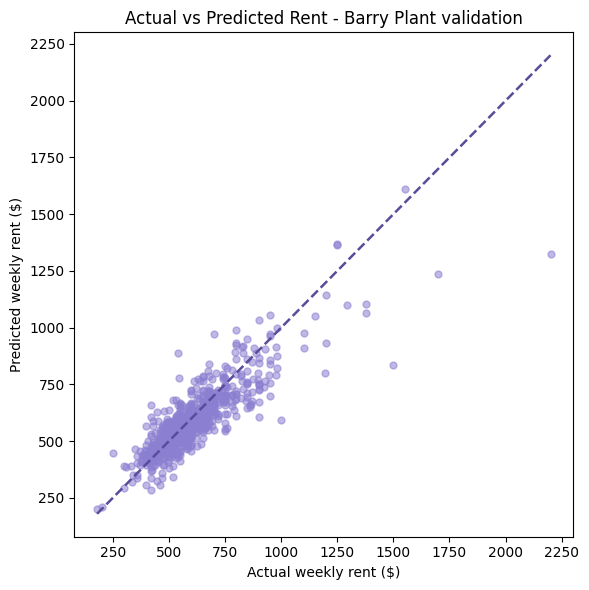

<Figure size 640x480 with 0 Axes>

In [8]:
plt.figure(figsize=(6, 6))

plt.scatter(validation_results["weekly_rent"],
            validation_results["predicted_rent"],
            s=25,
            alpha=0.55,
            color="#8B7FD1")

min_val = min(validation_results["weekly_rent"].min(),
                validation_results["predicted_rent"].min())

max_val = max(validation_results["weekly_rent"].max(),
                validation_results["predicted_rent"].max())

plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    linestyle="--",
    color="#5B4B9A",
    linewidth=1.8
)

plt.xlabel("Actual weekly rent ($)")
plt.ylabel("Predicted weekly rent ($)")
plt.title("Actual vs Predicted Rent - Barry Plant validation")

plt.tight_layout()
plt.show()
plt.savefig("../plots/actual_vs_predicted_barry_plant.png", dpi=300, bbox_inches="tight")

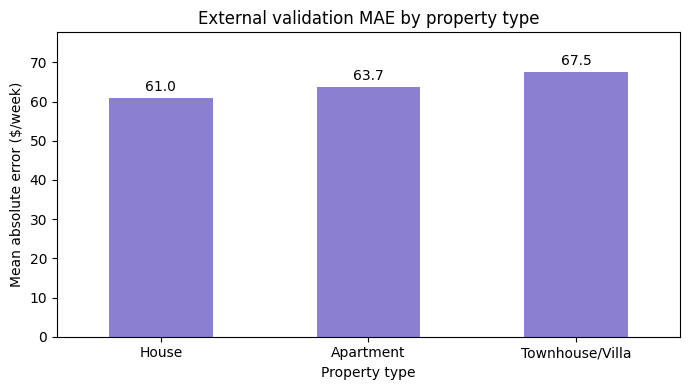

<Figure size 640x480 with 0 Axes>

In [9]:
type_mae = (validation_results
            .groupby("primary_type")["absolute_error"]
            .mean()
            .sort_values())

ax = type_mae.plot(kind="bar", color="#8B7FD1", figsize=(7, 4))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
    
ax.set_ylim(0, type_mae.max() * 1.15)

plt.xlabel("Property type")
plt.ylabel("Mean absolute error ($/week)")
plt.title("External validation MAE by property type")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
plt.savefig("../plots/external_validation_mae_by_property_type.png", dpi=300, bbox_inches="tight")

## Summary

The 2025 Domain model was evaluated on 719 independent 2026 Barry Plant listings without refitting or recalibrating the pipeline.

External validation performance:
- MAE: $62.61/week
- RMSE: $92.70
- R²: 0.728

Detailed interpretation is left to the project summary and presentation.